# Area Habitat Statistics

## Your Area Statistics

Land cover, Habitat types and Water hydroperiod are all Living wales layers spanning years from 2018-2023. Using this notebook we can quantify the area and percentage covered by each land cover class or habitat type as well as the proportion of the land covered by water (hydroperiod).

This notebook stems from a novel and unique collaboration between Monmouthshire County, Aberystwyth University, Dwr Cymru Welsh Water and Natural Resources Wales that linked *Living Wales*, to national initiatives that give free and open access to remotely sensed data and products to support wise use of the Welsh landscape and a better collective outlook for current and future generations.

## Information about your area.

This Notebook extracts information on your area for different years from the newly developed Welsh Data Cube (WDC), which houses all satellite data acquired over Wales since 2018 and derived products with these including land cover, broad habitats and water/moisture persistence.  

**Land Cover** is the physical and biological cover of the land surface and includes vegetation (managed or semi-natural), water and bare surfaces.  The land cover maps generated through Living Land Management use the legends of the United Nation's Food and Agriculture Organisation (FAO) Land Cover Classification System (LCCS).

**Habitats** represent the natural environments in which individual or groups of plant or animal species lives.  The habitat maps are generated from satellite data and are based on Wales' Phase 1 Habitat Taxonomy.

The **water/moisture persistence** is obtained from time-series of radar data that are acquired almost every day over Wales and indicate relative frequency of wet conditions across the landscape.  

# 0. Load Functions

In [3]:
import os
import sys

import datacube
import pandas as pd
import numpy as np
import geopandas as gpd

from datacube.utils.geometry import Geometry, CRS
from ipyleaflet import GeoData

from matplotlib.colors import ListedColormap
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.append("../wales_utils/data_cube_utilities")
sys.path.append("../utils")


from display_tools import map_geom, rgb
from wdc_datahandling import geopolygon_masking

## Define a function to produce summary statistics

For code that will be used multiple times in a notebook it is cleaner to define a function that can be called later. Here we create a function that will perform summary statistics and print them out. We'll come back to this function later in the notebook.

In [58]:
def stat_summary(xarr, scheme):
    """
    A function to perform summary statistics on an xarray object and return as a pandas
    dataframe.
    """
    # Search habitat types in farm
    farm_types = np.unique(xarr, return_counts=True)

    # Create dictionary to store outputs. Will convert this to a pandas data frame
    out_stat_dict = {"CATEGORY": [], "HECTARE": []}

    for color, label in scheme.items():
        if (label[0] in farm_types[0]) & (label[0] != 0):
            out_stat_dict["CATEGORY"].append(label[1])
            area_ha = (farm_types[1][list(farm_types[0]).index(label[0])] * 100) / 10000
            out_stat_dict["HECTARE"].append(area_ha)

    # Convert to a pandas dataframe
    out_stat_df = pd.DataFrame.from_dict(out_stat_dict)

    # Calculate percentage
    out_stat_df["PERCENT"] = 100*out_stat_df["HECTARE"] / out_stat_df["HECTARE"].sum()
    return out_stat_df

# 1. AREA  selection

Here you can choose the location of your site by: 
- Your own USER UPLOADS
- DRAW AND AREA
- View a model dataset for this notebook in CASE-STUDIES, or
- Choose a Welsh dataset

You may choose to add a buffer and add this to your site or subtract your site to visualise the buffer area only

## Load area selection functions

In [4]:
import notebook_dropdowns


## 1.1 Select an area

In [5]:
# initialization of site selection #
polygon_select = notebook_dropdowns.area_selection()

HTML(value="<b style='color:#1a2172'> Use the dropdown menu below to select areas or sites for analysis <p> Us…

Dropdown(description='Area Selection Type', layout=Layout(width='40%'), options=('1. User uploads', '2. DRAW A…

Dropdown(description='Filter dataset or select all', layout=Layout(width='40%'), options=('bbnp boundary', 'bl…

Dropdown(description='OPTIONAL - Select a site', layout=Layout(width='40%'), options=(), style=DescriptionStyl…

Button(description='Reset', style=ButtonStyle())

## 1.1.1 *OPTIONAL*  View dataset

In [78]:
site_df = notebook_dropdowns.view_selected_polygon(polygon_select)
site_df#
# or just run "notebook_dropdowns.view_selected_polygon(polygon_select)"  to view only


,objectid,sssi_name,sssi_id,sssi_code,first_noti,last_notif,confirmed,last_edite,registered,cartesian_,spherical_,centre_x,centre_y,osmm_date,type,status,geometry,fid
0,4513.0,Black Mountains,451.0,33WHL,1954-01-01,1985-01-28,1986-12-01,2008-11-24,Spherical,6765.632147,6745.34,323683.361577,228700.12673,2006-06-15,Biological,Confirmed,"POLYGON ((329322.19 228430.152, 329321.11 2284...",0


## 1.1.2 *OPTIONAL* View site shape and area

Generating Plot ...


IntProgress(value=0)

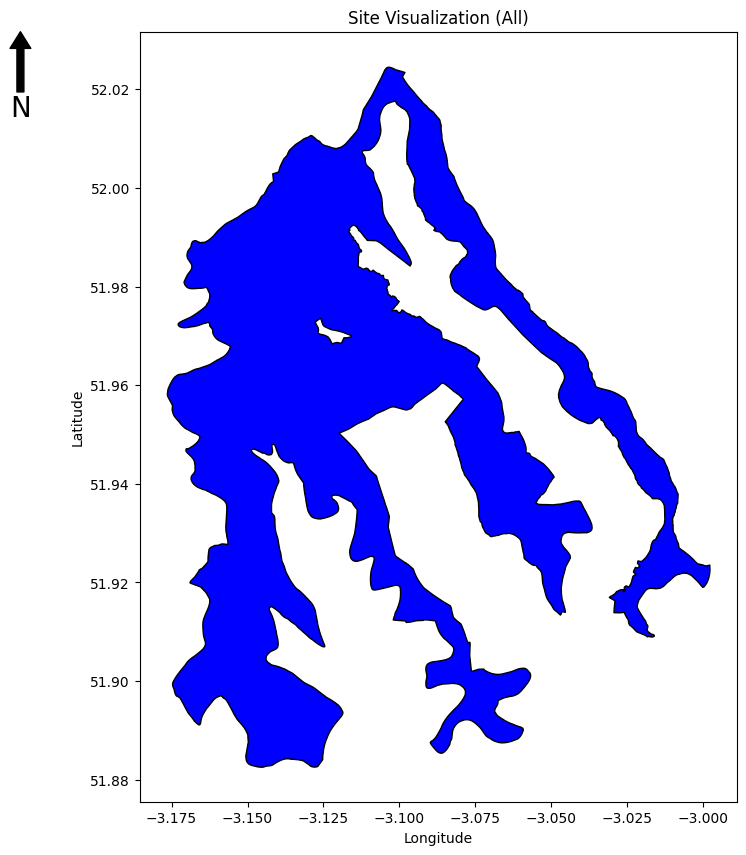

Total area: 17792.99 ha


In [79]:
#  plot selected vector/polygon to confirm
notebook_dropdowns.plot_selected_polygon(polygon_select)


## 1.1.3 Select site on a map

Here you will be able to 
- Draw an area
- Select a site from a group, or
- Confirm your chosen site

In [80]:
#  map to select or draw site
notebook_dropdowns.map_and_select_area(polygon_select)

Generating Interactive Map ...


IntProgress(value=0)

HTML(value="<b style='color:#1a2172'> Follow instructions below to correctly select area of interest. </b><br>…

## 1.1.4 *OPTIONAL* View selected or drawn dataset

In [81]:
#  display what selected area is
selected_polygon = notebook_dropdowns.polygon_selected()
selected_polygon


,objectid,sssi_name,sssi_id,sssi_code,first_noti,last_notif,confirmed,last_edite,registered,cartesian_,spherical_,centre_x,centre_y,osmm_date,type,status,geometry,fid
0,4513.0,Black Mountains,451.0,33WHL,1954-01-01,1985-01-28,1986-12-01,2008-11-24,Spherical,6765.632147,6745.34,323683.361577,228700.12673,2006-06-15,Biological,Confirmed,"POLYGON ((329322.19 228430.152, 329321.11 2284...",0


## 1.1.5 CONFIRM site below 

In [82]:
#  visualize selected option (add loading bar)
notebook_dropdowns.visualize_selected_area()

HTML(value="<b style='color:#1a2172'> Check that area displayed is your area of interest before proceeding, if…

Map(center=[np.float64(51.95360894470007), np.float64(-3.087247489208834)], controls=(ZoomControl(options=['po…

## 1.2 Would you like to add a buffer around your site? 

If you DO NOT require a buffer proceed to section 2.0

#### 1.2.1 Choose buffer distance

In [7]:
# select buffer amount controls (you don't need to click confirm buffer button, once radio btn for option is clicked, it sets it)
notebook_dropdowns.include_buffer()

In [15]:
# Confirm the active selected buffer amount is 
notebook_dropdowns.active_buffer()

HTML(value=" <p style='color:black'>  Buffer distance:  <b style='color:'>  0.1 km (100 meters) </b>  </p>")

### 1.2.2. Visualise Buffer + Site on a Map

In [22]:
#  run the buffer and include selection method and visualize it 
notebook_dropdowns.buffer_include_selection()

Map(center=[np.float64(52.41966470093185), np.float64(-3.9732922425565267)], controls=(ZoomControl(options=['p…

### 1.2.3 Exclude site and retain BUFFER ONLY

In [10]:
#  run the buffer and exclude selection method and visualize it 
notebook_dropdowns.buffer_exclude_selection()

Map(center=[np.float64(51.95360363906262), np.float64(-3.087249151019682)], controls=(ZoomControl(options=['po…

### 1.2.4 CONFIRM site

In [12]:
#  visualise what has been selected
notebook_dropdowns.visualize_selected_area()


HTML(value="<b style='color:#1a2172'> Check that area displayed is your area of interest before proceeding, if…

Map(center=[np.float64(51.92304462201109), np.float64(-3.49192449329001)], controls=(ZoomControl(options=['pos…

## 1.3 Advanced Extras: 

- convert from Geopandas to GeoJson 
- convert from GeoJson to Geopandas

### 1.2.5 OPTIONAL Geopandas to GeoJson

In [ ]:
# if selected area data is in geopandas dataframe form, convert to GeoJson if needed 
geojson_format_selected_area = notebook_dropdowns.convert_to_geojson(selected_polygon)
geojson_format_selected_area

### 1.2.5 OPTIONAL GeoJson to Geopandas

In [ ]:
# if selected area data is in GeoJson  form, convert to  geopandas dataframe if needed
gpdf_format_selected_area = notebook_dropdowns.convert_to_geopandas_df(selected_polygon)
gpdf_format_selected_area

In [83]:
selected_polygon

,objectid,sssi_name,sssi_id,sssi_code,first_noti,last_notif,confirmed,last_edite,registered,cartesian_,spherical_,centre_x,centre_y,osmm_date,type,status,geometry,fid
0,4513.0,Black Mountains,451.0,33WHL,1954-01-01,1985-01-28,1986-12-01,2008-11-24,Spherical,6765.632147,6745.34,323683.361577,228700.12673,2006-06-15,Biological,Confirmed,"POLYGON ((329322.19 228430.152, 329321.11 2284...",0


# 2. Analysis

## Load in Data
Here we load in the Living Wales land cover and habitat products. These have been calculated and indexed into the open data cube so can be loaded as products.

In [ ]:
#TODO: build functionality
# year = notebook_dropdowns.year_select()
# area_name = notebook_dropdowns.area_name()

In [84]:
year = "2022"
area_name = "test_area_2"

In [85]:
dc = datacube.Datacube(app="Farms")

In [86]:
product = "lw_landcover_lw"

measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
level3,level3,uint8,1,0,"[l3, base]",NaN
lifeform,lifeform,uint8,1,0,[lifeform_veg_cat_l4a],NaN
leaftype,leaftype,uint8,1,0,[leaftype_veg_cat_l4a],NaN
phenology,phenology,uint8,1,0,[phenolog_veg_cat_l4a],NaN
waterpersist,waterpersist,uint8,1,0,"[water_persistence, water_seasonality, waterpe...",NaN


In [87]:
product = "lw_habitats_lw"

measurements = dc.list_measurements()
measurements.loc[product]

,name,dtype,units,nodata,aliases,flags_definition
measurement,,,,,,
detailed,detailed,uint8,1,0,[detailed_habitat],NaN
broad,broad,uint8,1,0,[broad_habitat],NaN


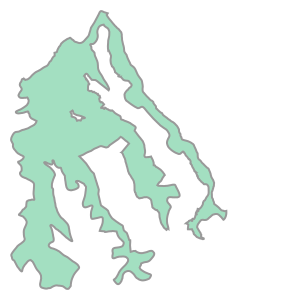

In [88]:
geom = Geometry(geom=selected_polygon.iloc[0].geometry, crs=CRS("EPSG:27700"))
geom

In [91]:
query = {
    "geopolygon": geom,
    "time": (year + "-01-01", year + "-12-31"),
    "output_crs": "EPSG:27700",
    "resolution": (-10, 10),
    "dask_chunks": {"y": 2048, "x": 2048},
}

In [92]:
# Load land cover data for our polygon and time period
lc_dataset = dc.load(product="lw_landcover_lw", **query)
lc_dataset_masked = geopolygon_masking(lc_dataset, geopolygon=geom)


In [93]:
level3plus = (
    lc_dataset_masked.level3.where(lc_dataset_masked.level3 == 112)
    + lc_dataset_masked.lifeform
).fillna(0) + (lc_dataset_masked.level3.where(lc_dataset_masked.level3 != 112)).fillna(
    0
)
lc_dataset["level3plus"] = level3plus

In [94]:
# Level3plus colour scheme
level3plus_scheme = {
    "#FFFFFF": [0.0, "Not classified"],
    "#D1E133": [111.0, "Cultivated or managed terrestrial vegetation"],
    "#007A02": [113.0, "Semi-natural terrestrial woody vegetation"],
    "#95c748": [114.0, "Semi-natural terrestrial herbaceous vegetation"],
    "#4EEEE8": [123.0, "Cultivated or managed aquatic vegetation"],
    "#02C077": [124.0, "Semi-natural aquatic vegetation"],
    "#DA5C69": [215.0, "Artificial surface"],
    "#F3AB69": [216.0, "Bare surface"],
    "#4D9FDC": [220.0, "Water"],
}

# Colour map
level3plus_cmap = ListedColormap(list(level3plus_scheme.keys()))
# Level3plus classes
# Define a normalization from values -> colors
level3plus_norm = colors.BoundaryNorm(
    [value[0] for value in level3plus_scheme.values()], 9
)

## Plot Land Cover Map

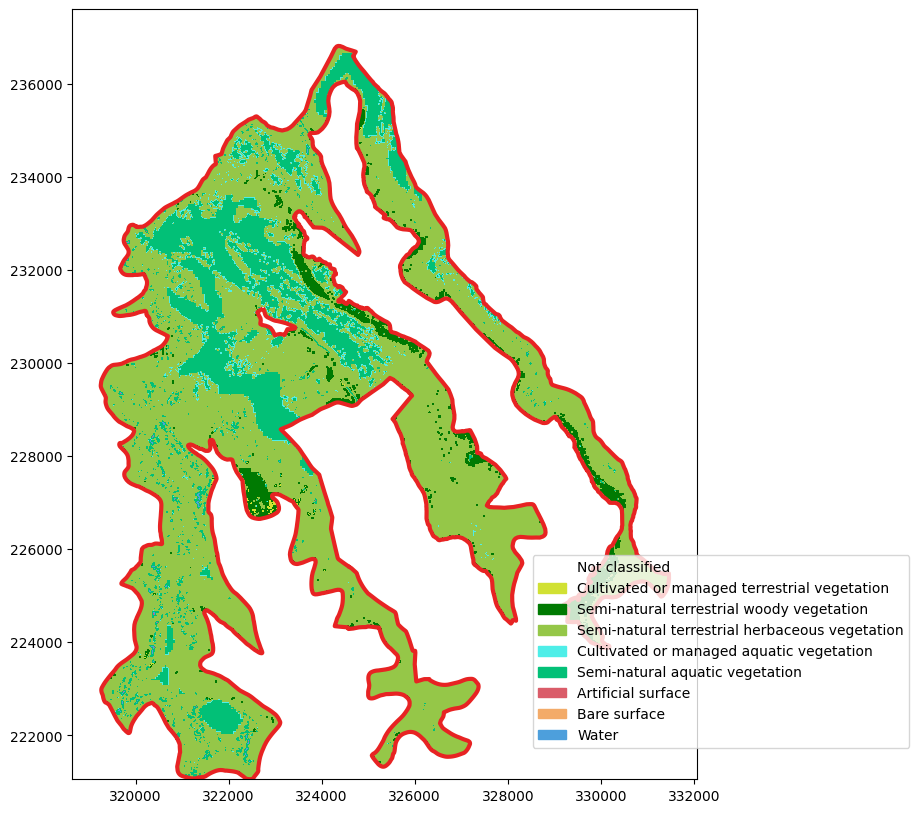

In [95]:
# Plotting
lc_fig, ax = plt.subplots(figsize=(20, 10))

lc_plot = ax.imshow(
    lc_dataset.level3plus.isel(time=0),
    cmap=level3plus_cmap,
    norm=level3plus_norm,
    extent=[
        lc_dataset.x.min().data,
        lc_dataset.x.max().data,
        lc_dataset.y.min().data,
        lc_dataset.y.max().data,
    ],
)

# Specify if want to show bounds on image (if they exist)
show_bounds = True
if show_bounds:
    selected_polygon.boundary.plot(ax=ax, ec="#e72323", linewidth=3)

patches = [
    Patch(color=color, label=label[1]) for color, label in level3plus_scheme.items()
]

ax.legend(handles=patches, bbox_to_anchor=(1.35, 0.3), facecolor="white")

# ax.set_axis_off()
plt.show()

### Save Figures to file
The figure can be saved out as a PNG file for inclusion in reports. It is also possible to skip the `show` command and just save the figure to a file, this can be useful when producing a lot of figures (e.g., for different years).

In [96]:

lc_fig.savefig(f"Land_cover_{area_name}_{year}.png")

## Quantify the area of each land cover in your area

Here we are using the `stat_summary` function defined at the start of the notebook to print summary satistics.

In [97]:
landcover_stats_df = stat_summary(lc_dataset.level3plus, level3plus_scheme)
landcover_stats_df

,CATEGORY,HECTARE,PERCENT
0,Cultivated or managed terrestrial vegetation,6.89,0.101838
1,Semi-natural terrestrial woody vegetation,214.22,3.166298
2,Semi-natural terrestrial herbaceous vegetation,4989.67,73.750264
3,Semi-natural aquatic vegetation,1477.68,21.840982
4,Artificial surface,1.68,0.024831
5,Bare surface,3.07,0.045376
6,Water,72.42,1.070410


### Calculate the total area
Not the results are in a Pandas data frame it is possible to perform different statistics on them, for example the sum to get the total area

In [98]:
total_area = landcover_stats_df["HECTARE"].sum()
print(f"Total area {total_area:.2f} ha")

Total area 6765.63 ha


## Produce some plots
Pandas also has built in functions to produce plots from the data. Here we are going to produce a pie chart to show the proportion of each category

<Axes: ylabel='Area'>

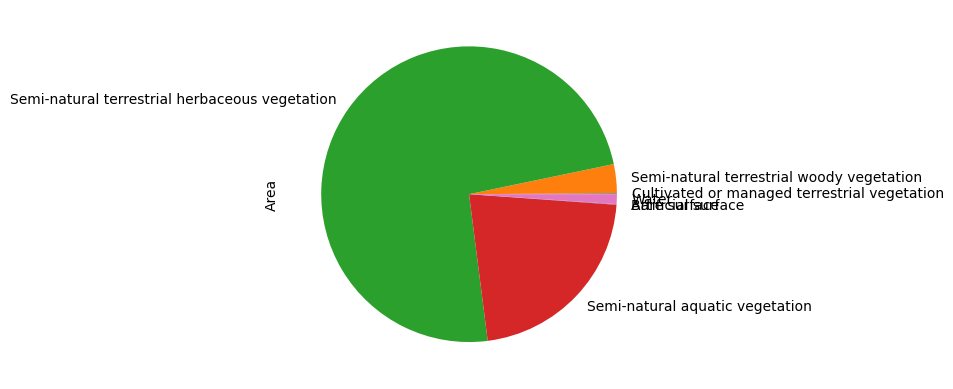

In [99]:
landcover_stats_df.set_index("CATEGORY").plot.pie(
    y="HECTARE", legend=False, ylabel="Area"
)

### Save out to a CSV file
It is also possible to save out pandas dataframes to a CSV file so they can be opened in Excel. Here we are specifying we only want outputs to two decimal places using `float_format`.

In [100]:
landcover_stats_df.to_csv(
    f"Land_cover_{area_name}_{year}_stats.csv", float_format="%.2f", index=False
)

## Habitat data
We can perform a similar process of subsetting data and calculating statistics using the habitat data provided by Living Wales.

In [101]:
# Load habitat data for our polygon and time period
habitat_dataset = dc.load(product="lw_habitats_lw", **query)
habitat_dataset_masked = geopolygon_masking(habitat_dataset, geopolygon=geom)

In [102]:
# Level3plus colour scheme
broadhabitat_scheme = {
    "#FFFFFF": [0.0, "Not classified"],
    "#00C502": [1.0, "Broadleaved woodland"],
    "#006902": [2.0, "Needle-leaved woodland"],
    "#CEF191": [3.0, "Semi-natural grassland"],
    "#C91FCC": [4.0, "Heathland and Scrub"],
    "#F2A008": [5.0, "Bracken"],
    "#F8F8C9": [6.0, "Bog"],
    "#177E88": [7.0, "Fen/Marsh/Swamp"],
    "#FFFF00": [8.0, "Cultivated or managed vegetation"],
    "#00DDA4": [9.0, "Coastal habitat"],
    "#0E00ED": [10.0, "Open Water"],
    "#908E8D": [11.0, "Natural Bare Surfaces"],
    "#000000": [12.0, "Artificial Bare Surfaces"],
    "#DAC654": [13.0, "Young trees/Felled/Coppice"],
    "#5d994e": [14.0, "Woodland and scrub"],
}

# Habitat colour scheme
broadhabitat_cmap = ListedColormap(list(broadhabitat_scheme.keys()))
# Habitat classes
broadhabitat_norm = colors.BoundaryNorm(
    [value[0] for value in broadhabitat_scheme.values()], 15
)

### Plot Habitat map

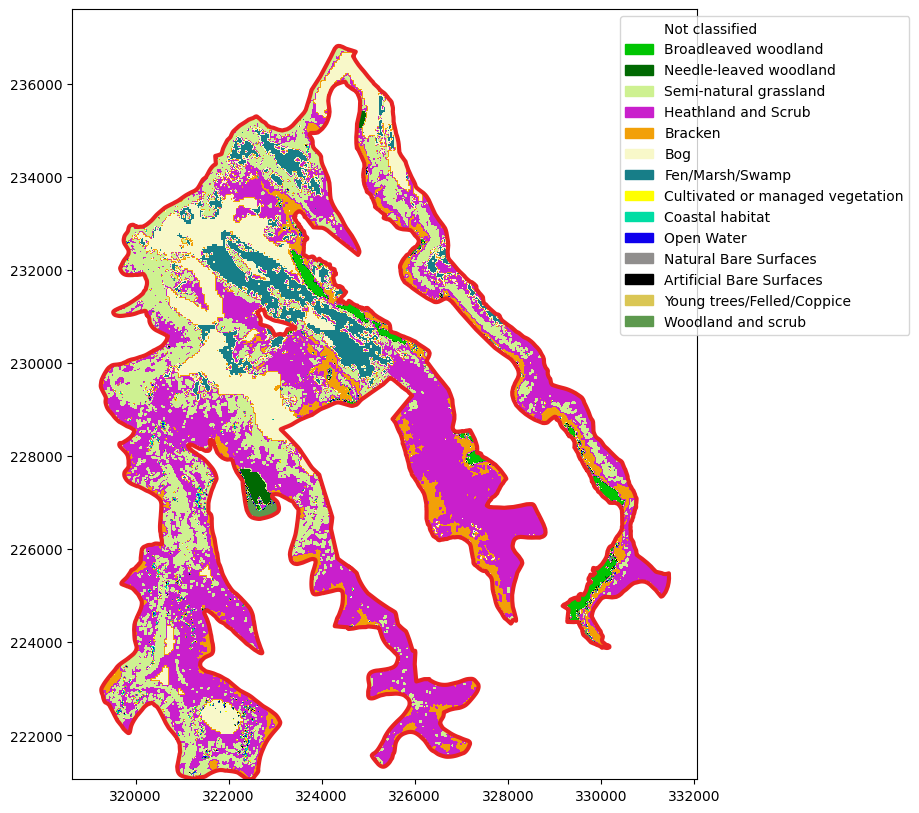

In [103]:
# Plotting
habitat_fig, ax = plt.subplots(figsize=(20, 10))

habitat_plot = ax.imshow(
    habitat_dataset_masked.broad.isel(time=0),
    cmap=broadhabitat_cmap,
    norm=broadhabitat_norm,
    extent=[
        habitat_dataset.x.min().data,
        habitat_dataset.x.max().data,
        habitat_dataset.y.min().data,
        habitat_dataset.y.max().data,
    ],
)

show_bounds = True
if  show_bounds:
    selected_polygon.boundary.plot(ax=ax, ec="#e72323", linewidth=3)


patches = [
    Patch(color=color, label=label[1]) for color, label in broadhabitat_scheme.items()
]

ax.legend(handles=patches, bbox_to_anchor=(1.35, 1), facecolor="white")

# ax.set_axis_off()
plt.show()

### Save the figure to a file

In [104]:
habitat_fig.savefig(f"Broad_habitats_{area_name}_{year}.png")

### Quantify the area of each habitat in your area

In [105]:
habitat_stats_df = stat_summary(habitat_dataset_masked.broad, broadhabitat_scheme)
habitat_stats_df

,CATEGORY,HECTARE,PERCENT
0,Broadleaved woodland,129.63,1.921128
1,Needle-leaved woodland,35.73,0.529522
2,Semi-natural grassland,958.24,14.201197
3,Heathland and Scrub,3187.95,47.245687
4,Bracken,889.13,13.176981
5,Bog,734.33,10.882832
6,Fen/Marsh/Swamp,705.08,10.449345
7,Cultivated or managed vegetation,6.77,0.100332
8,Open Water,43.66,0.647045
9,Natural Bare Surfaces,1.34,0.019859


You may want to produce some plots or save to a CSV, as for land cover.

## Water persistance data

In [106]:
# Level3plus colour scheme
waterper_scheme = {
    "#FFFFFF": [0.0, "Not affected"],
    "#0a549e": [1.0, "9+ months"],
    "#2172b6": [2.0, "8 months"],
    "#3e8ec4": [3.0, "7 months"],
    "#60a6d2": [4.0, "6 months"],
    "#89bfdd": [5.0, "5 months"],
    "#b0d2e8": [6.0, "4 months"],
    "#cde0f2": [7.0, "3 months"],
    "#cde0f2": [8.0, "2 months"],
    "#e8f2fb": [9.0, "1 month"],
}

# Water/wetness persistence colour scheme
waterper_cmap = ListedColormap(list(waterper_scheme.keys()))
# Habitat classes
waterper_norm = colors.BoundaryNorm(
    [value[0] for value in waterper_scheme.values()], 11
)

### Map Water persistence

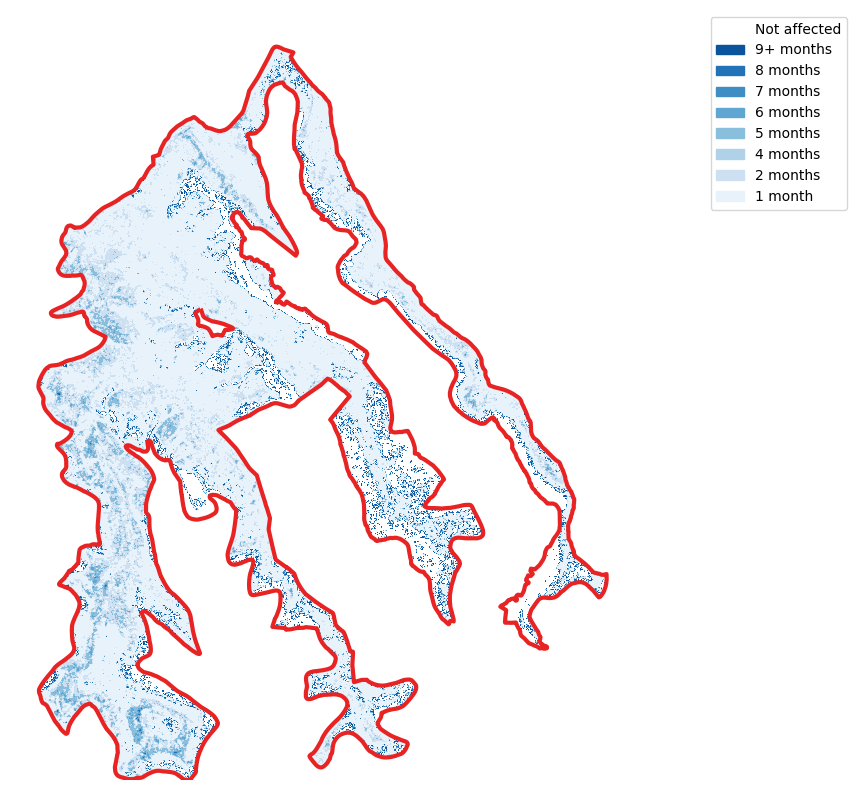

In [107]:
# Plotting
waterper_fig, ax = plt.subplots(figsize=(20, 10))

waterper_plot = ax.imshow(
    lc_dataset_masked.waterpersist.isel(time=0),
    cmap=waterper_cmap,
    norm=waterper_norm,
    extent=[
        lc_dataset.x.min().data,
        lc_dataset.x.max().data,
        lc_dataset.y.min().data,
        lc_dataset.y.max().data,
    ],
)

show_bounds = True
if   show_bounds:
    selected_polygon.boundary.plot(ax=ax, ec="#e72323", linewidth=3)

patches = [
    Patch(color=color, label=label[1]) for color, label in waterper_scheme.items()
]

ax.legend(handles=patches, bbox_to_anchor=(1.35, 1), facecolor="white")
ax.set_axis_off()
plt.show()

### Save the figure to a file

In [108]:
waterper_fig.savefig(f"Soil_moisture_persistence_{area_name}_{year}.png")

### Show how much land has persistant water on the surface for how long

In [109]:
waterper_stats_df = stat_summary(lc_dataset_masked.waterpersist, waterper_scheme)
waterper_stats_df

,CATEGORY,HECTARE,PERCENT
0,9+ months,0.09,0.002228
1,8 months,1.31,0.032428
2,7 months,17.78,0.440126
3,6 months,141.26,3.496751
4,5 months,553.35,13.697630
5,4 months,1137.37,28.154465
6,2 months,972.90,24.083173
7,1 month,1215.69,30.093199
